In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.cluster.hierarchy import linkage, leaves_list
from scipy.spatial.distance import squareform
import os
import sys

sys.path.append(os.path.abspath("../../repos/RiskLabAI.py"))
from src.quantum_hrp import compute_financial_features, fetch_stock_data, average_density_matrix, compute_distance_matrix, quantum_ordering, classical_hrp_ordering, simulate_asset_features_regimes



In [2]:
returns = pd.read_csv(
    "../../data/returns.csv",
    index_col=0,
    parse_dates=True
)

features = np.load("../../data/features.npy")

print(type(returns))
print(returns.shape)

print(type(features))
print(features.shape)




<class 'pandas.core.frame.DataFrame'>
(616, 169)
<class 'numpy.ndarray'>
(169, 616, 6)


In [3]:
asset_returns = returns.values


In [4]:
corr = np.corrcoef(asset_returns, rowvar=False)

print(np.min(corr), np.max(corr))



-0.1700817888734922 1.0


In [5]:
def plot_corr_matrix(C, title):
    plt.figure(figsize=(6, 5))
    im = plt.imshow(
        C,
        cmap="coolwarm",
        vmin=-0.2,
        vmax=1,
        interpolation="nearest"
    )
    plt.colorbar(im, fraction=0.046, pad=0.04)
    plt.title(title)
    plt.xticks([])
    plt.yticks([])
    plt.tight_layout()
    plt.show()


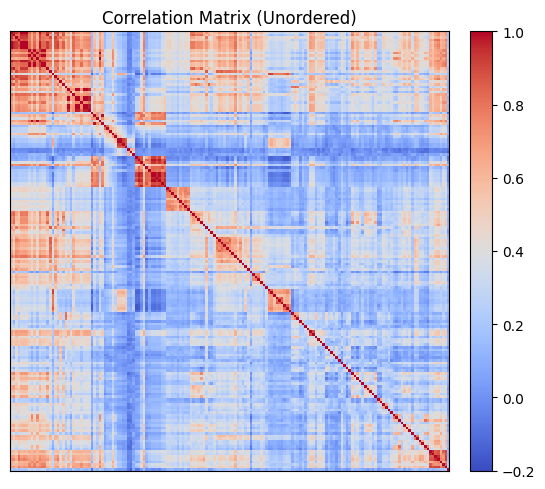

In [6]:
plot_corr_matrix(corr, "Correlation Matrix (Unordered)")


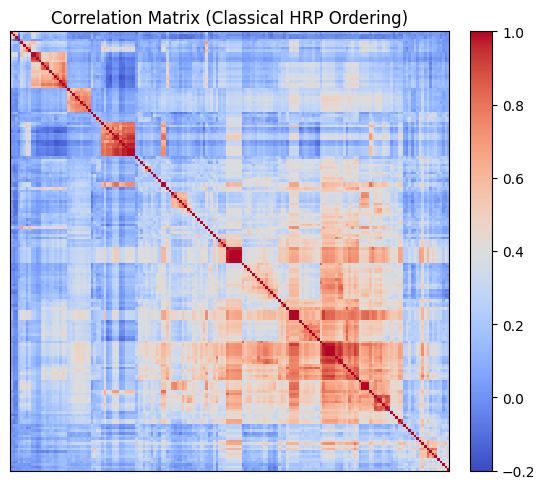

In [7]:
order_hrp = classical_hrp_ordering(asset_returns)
corr_hrp = corr[np.ix_(order_hrp, order_hrp)]

plot_corr_matrix(corr_hrp, "Correlation Matrix (Classical HRP Ordering)")


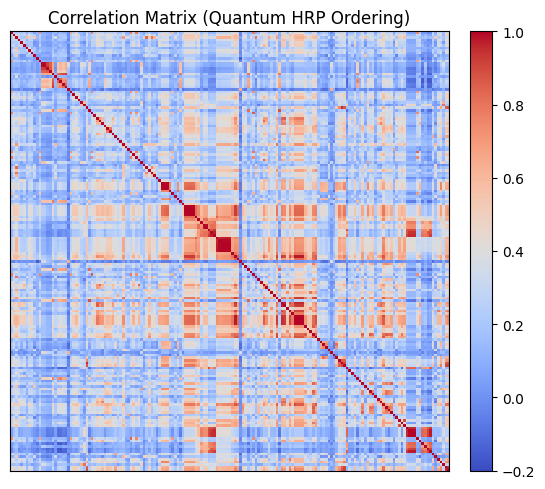

In [8]:
rho_list = []
N = features.shape[0]

for i in range(N):
    rho_i = average_density_matrix(features[i], alpha=2.0)
    rho_list.append(rho_i)

D_quantum = compute_distance_matrix(rho_list)
order_qhrp = quantum_ordering(D_quantum)

corr_qhrp = corr[np.ix_(order_qhrp, order_qhrp)]

plot_corr_matrix(corr_qhrp, "Correlation Matrix (Quantum HRP Ordering)")
